In [1]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn torch

In [2]:
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,                        # converts text to token IDs
    AutoModelForSequenceClassification,   # transformer + classification head
    TrainingArguments,                    # training hyperparameters
    Trainer,                              # handles training loop
    EarlyStoppingCallback                 # stops training if no improvement
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
# Amazon Polarity dataset
# Labels:
# 0 = Negative review
# 1 = Positive review

from datasets import load_dataset

dataset = load_dataset(
    "fancyzhx/amazon_polarity",
    split={
        "train": "train[:5000]",
        "test": "test[:1000]"
    }
)

print("DATASET OVERVIEW")
print(dataset)

# Check class balance
pos = sum(dataset["train"]["label"])
neg = len(dataset["train"]["label"]) - pos

print("\nCLASS DISTRIBUTION")
print(f"Positive reviews: {pos}")
print(f"Negative reviews: {neg}")

# Display first 10 reviews
print("\n" + "=" * 60)
print("FIRST 10 REVIEWS")
print("=" * 60)

for i in range(10):

    sample = dataset["train"][i]

    label = "Positive ✓" if sample["label"] == 1 else "Negative ✗"

    print(f"\n[{i+1}] {label}")
    print("Title :", sample["title"])
    print("Review:", sample["content"][:150], "...")

DATASET OVERVIEW
DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 1000
    })
})

CLASS DISTRIBUTION
Positive reviews: 2308
Negative reviews: 2692

FIRST 10 REVIEWS

[1] Positive ✓
Title : Stuning even for the non-gamer
Review: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played t ...

[2] Positive ✓
Title : The best soundtrack ever to anything.
Review: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinin ...

[3] Positive ✓
Title : Amazing!
Review: This soundtrack is my favorite music of all time, hands down. The intense sadness of "Prisoners of Fate" (which means all the more if you've played th ...

[4] Positive ✓
Title : Excellent Soundtrack

In [11]:
import re

# Remove HTML, URLs and extra spaces
def clean_text(text):

    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
from transformers import AutoTokenizer

# Convert text into tokens that transformers understand
def tokenize(model_name, dataset):

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(batch):

        cleaned = [clean_text(text) for text in batch["content"]]

        return tokenizer(
            cleaned,
            truncation=True,
            padding="max_length",
            max_length=256
        )

    tokenized_dataset = dataset.map(tokenize_fn, batched=True)

    return tokenized_dataset, tokenizer

In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Evaluate model predictions
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [14]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

def train_model(model_name, dataset):

    print("\n" + "=" * 60)
    print(f"Training: {model_name}")
    print("=" * 60)

    # Prepare data
    tokenized, tokenizer = tokenize(model_name, dataset)

    # Load pretrained transformer
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

    # Training settings
    args = TrainingArguments(
        output_dir=f"./results/{model_name.split('/')[-1]}",
        num_train_epochs=4,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        weight_decay=0.01,
        warmup_steps=100,
        report_to="none"
    )

    # Trainer object
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    # Fine-tune model
    trainer.train()

    # Evaluate model
    results = trainer.evaluate()

    # Generate predictions
    preds_output = trainer.predict(tokenized["test"])

    preds = np.argmax(
        preds_output.predictions,
        axis=1
    )

    labels = list(tokenized["test"]["label"])

    return results, preds, labels

In [15]:
# Compare three transformer architectures
#
# BERT       : Original transformer baseline
# DistilBERT : Smaller and faster version of BERT
# RoBERTa    : Improved pretraining strategy

models = [
    "bert-base-uncased",
    "distilbert-base-uncased",
    "roberta-base"
]

results = {}
all_preds = {}
all_labels = {}

for model_name in models:

    res, preds, labels = train_model(
        model_name,
        dataset
    )

    results[model_name] = res
    all_preds[model_name] = preds
    all_labels[model_name] = labels

    print(f"\n✓ {model_name.split('/')[-1]}")
    print(f"Accuracy : {res['eval_accuracy']:.4f}")
    print(f"F1 Score : {res['eval_f1']:.4f}")


Training: bert-base-uncased


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✓ roberta-base
Accuracy : 0.9350
F1 Score : 0.9350


In [16]:
from sklearn.metrics import classification_report

best_model = "roberta-base"

print(
    classification_report(
        all_labels[best_model],
        all_preds[best_model],
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.92      0.95      0.94       498
    Positive       0.95      0.92      0.93       502

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.93      1000
weighted avg       0.94      0.94      0.93      1000



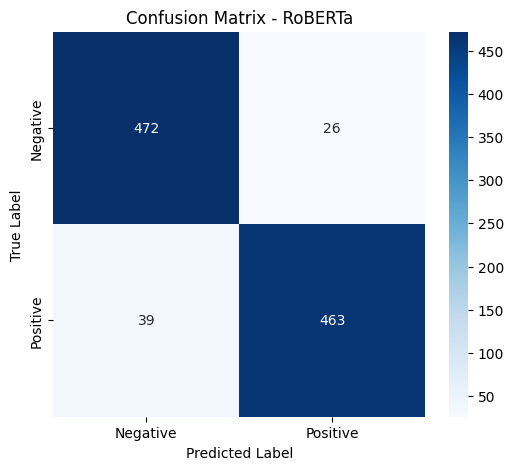

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = "roberta-base"

cm = confusion_matrix(
    all_labels[best_model],
    all_preds[best_model]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - RoBERTa")

plt.show()

In [18]:
import numpy as np

best_model = "roberta-base"

wrong_idx = np.where(
    np.array(all_preds[best_model]) != np.array(all_labels[best_model])
)[0]

print("Total wrong predictions:", len(wrong_idx))

Total wrong predictions: 65


In [21]:
best_model = "roberta-base"

wrong_idx = np.where(
    np.array(all_preds[best_model]) !=
    np.array(all_labels[best_model])
)[0]

for idx in wrong_idx[:10]:

    idx = int(idx)

    print("\n" + "="*80)

    print("Review:")
    print(dataset["test"][idx]["content"][:300])

    print(
        "\nTrue:",
        "Positive" if all_labels[best_model][idx] == 1 else "Negative"
    )

    print(
        "Pred:",
        "Positive" if all_preds[best_model][idx] == 1 else "Negative"
    )


Review:
Firstly,I enjoyed the format and tone of the book (how the author addressed the reader). However, I did not feel that she imparted any insider secrets that the book promised to reveal. If you are just starting to research law school, and do not know all the requirements of admission, then this book 

True: Negative
Pred: Positive

Review:
Parricia Corwell, Cruel & Unusual was breathtaking in the beginning! Her relation to her family, her dedication to her work exeptional. However, this story began to get boring towards the end...the ending, not too great.

True: Positive
Pred: Negative

Review:
This has just about everything. The rabbi, of course, is learned and devout, even if his schooling causes some nervousness. The cat becomes fantastical when some mystery grants him human speech. The visit abroad captures all the distrust of the alien that the most insular of small-towners can summon

True: Positive
Pred: Negative

Review:
the publisher said soon to be a movie. does anyo

In [22]:
import pandas as pd

results_table = pd.DataFrame({
    "Model": [m.split("/")[-1] for m in results.keys()],
    "Accuracy": [results[m]["eval_accuracy"] for m in results],
    "F1 Score": [results[m]["eval_f1"] for m in results]
})

results_table = results_table.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_table)

                     Model  Accuracy  F1 Score
2             roberta-base     0.935  0.934992
0        bert-base-uncased     0.923  0.923000
1  distilbert-base-uncased     0.910  0.909997


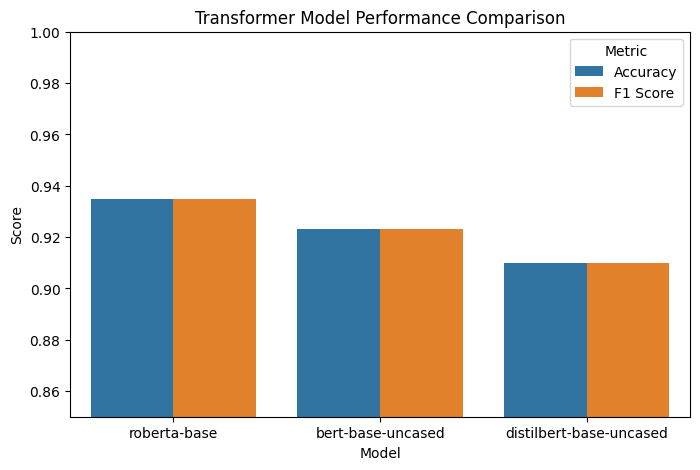

In [23]:
plot_df = results_table.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Transformer Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.85, 1.00)

plt.show()